# 3.1. Practica 1: Análisis, implementación y prueba de máquinas de aprendizaje supervisado (Parte II)

## Introducción de la actividad.

Dada una base de datos 𝐷={𝑡1,𝑡2,…,𝑡𝑛} de tuplas o registros (individuos) y un conjunto de clases 𝐶={𝐶1,𝐶2,…,𝐶𝑚}, el problema de la clasificación es encontrar una función 𝑓:𝐷→𝐶 tal que cada 𝑡𝑖 es asignada una clase 𝐶𝑗. 𝑓:𝐷→𝐶 podría ser Random Forest, una Red Neuronal, una Máquina de Soporte Vectorial, etc.

El análisis, implementación y prueba de máquinas de aprendizaje supervisado (**Parte II: Random Forest, una Red Neuronal, una Máquina de Soporte Vectorial**), permitirá comprender el funcionamiento de forma clara y precisa.
 
## Propósito de la actividad.

Comprender el funcionamiento de las máquinas de aprendizaje supervisado (**Parte II: Random Forest, Red Neuronal, Máquina de Soporte Vectorial**).

## Instrucciones.

Analice, implemente y pruebe máquinas de aprendizaje supervisado (**Parte II: Random Forest, una Red Neuronal, una Máquina de Soporte Vectorial**), la implementación de las máquinas será en el lenguaje de su preferencia. Deberá contener:

Análisis de las máquinas de aprendizaje supervisado (explique el funcionamiento del LOOCV con los modelos predictivos (utilice al menos dos algoritmos)).

Implementación de las máquinas de aprendizaje supervisado (implementación del LOOCV con los modelos predictivos (utilice al menos dos algoritmos)).

Prueba de las máquinas de aprendizaje supervisado (Análisis comparativo de modelos predictivos utilizando: la Precisión Global, el Error Global, la Precisión Positiva (PP), la Precisión Negativa (PN), los Falsos Positivos (FP), los Falsos Negativos (FN), la Asertividad Positiva (AP) y la Asertividad Negativa (NP). Utilice al menos dos algoritmos predictivos con la técnica LOOCV).

Conclusiones.

Referencias en formato APA

## Dependencias

| Librería | Propósito en esta práctica |
|---|---|
| `numpy` | Operaciones vectoriales, construcción de matrices de confusión y cálculo de las métricas de evaluación |
| `pandas` | Inspección tabular del dataset y construcción de las tablas comparativas de métricas |
| `matplotlib` | Visualización de la proyección PCA, las matrices de confusión y las gráficas comparativas |
| `scikit-learn` | Dataset (`load_wine`), utilidades de validación cruzada y los tres modelos predictivos (`RandomForestClassifier`, `SVC`, `MLPClassifier`) |

In [9]:
import sys
import subprocess
import importlib.util

required = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "scikit-learn": "sklearn",
}

for package, import_name in required.items():
    if importlib.util.find_spec(import_name) is None:
        print(f"Instalando {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

import numpy as np
import pandas as pd
import matplotlib
import sklearn

print(f"Python       {sys.version}")
print(f"numpy        {np.__version__}")
print(f"pandas       {pd.__version__}")
print(f"matplotlib   {matplotlib.__version__}")
print(f"scikit-learn {sklearn.__version__}")

Python       3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
numpy        2.3.3
pandas       2.3.3
matplotlib   3.10.7
scikit-learn 1.7.2


## Dataset: Wine recognition (binarizado)

Se utiliza el dataset **Wine recognition data** (Aeberhard, Coomans & de Vel, 1992), incluido en scikit-learn. Su tarea original es **multiclase** (distinguir 3 cultivares de vid), por lo que se **binariza** con un enfoque uno-contra-el-resto: se define como clase positiva el **Cultivar 1** frente a la clase negativa **"Otros cultivares"** (Cultivar 0 y Cultivar 2 combinados). Esto permite conservar, sin modificar su definición, las métricas binarias de la práctica (PP, PN, AP, NP, etc.). Reutilizar este mismo dataset binarizado en la Práctica 3.2 ([enlace](https://github.com/RKCbas/Maestria-en-Inteligencia-Artificial---Practicas/blob/main/Cuatrimestre%203/6%20-%20Aprendizaje%20inteligente/Practica%203/3.2.%20An%C3%A1lisis%2C%20implementaci%C3%B3n%20y%20prueba%20de%20m%C3%A1quinas%20de%20aprendizaje%20supervisado%20(Parte%20II).ipynb)) es intencional: permite comparar, sobre **el mismo problema**, cómo se comporta LOOCV frente a K-Folds, sin que las diferencias observadas se deban a que los datos cambiaron.

No es necesario descargarlo manualmente: **scikit-learn lo incluye empaquetado** y se carga de forma local, sin conexión a internet:

```python
from sklearn.datasets import load_wine
```

**Características (13, numéricas):** resultado de un análisis químico de vinos cultivados en la misma región de Italia pero derivados de tres cultivares distintos (alcohol, ácido málico, ceniza, alcalinidad de la ceniza, magnesio, fenoles totales, flavonoides, fenoles no flavonoides, proantocianinas, intensidad de color, tono, OD280/OD315 de vinos diluidos y prolina).

**Clase objetivo (`target`, binarizada):**
- **1** — Cultivar 1 (clase positiva)
- **0** — Otros cultivares: Cultivar 0 + Cultivar 2 (clase negativa)

**Tamaño:** 178 muestras — un tamaño moderado que permite ejecutar **LOOCV** (que exige entrenar un modelo distinto por cada muestra) en tiempos razonables.

In [10]:
from sklearn.datasets import load_wine

dataset = load_wine()
X = dataset.data
y = (dataset.target == 1).astype(int)  # 1 = Cultivar 1 (positiva), 0 = Otros cultivares (negativa)

df = pd.DataFrame(X, columns=dataset.feature_names)
df["target"] = y

print(f"Muestras: {X.shape[0]}, características: {X.shape[1]}")
print(f"Clases: {dict(zip(*np.unique(y, return_counts=True)))} (0=otros cultivares, 1=cultivar 1)")
df.head()

Muestras: 178, características: 13
Clases: {np.int64(0): np.int64(107), np.int64(1): np.int64(71)} (0=otros cultivares, 1=cultivar 1)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


### Balance de clases y separabilidad

Antes de entrenar cualquier modelo conviene revisar dos cosas: si las clases están razonablemente balanceadas (si no lo estuvieran, la exactitud dejaría de ser una métrica confiable por sí sola) y si, a simple vista, existe alguna estructura que separe las clases. Para lo segundo se proyectan las 13 características a 2 dimensiones con PCA (solo con fines de visualización; los modelos se entrenarán con las 13 características originales).

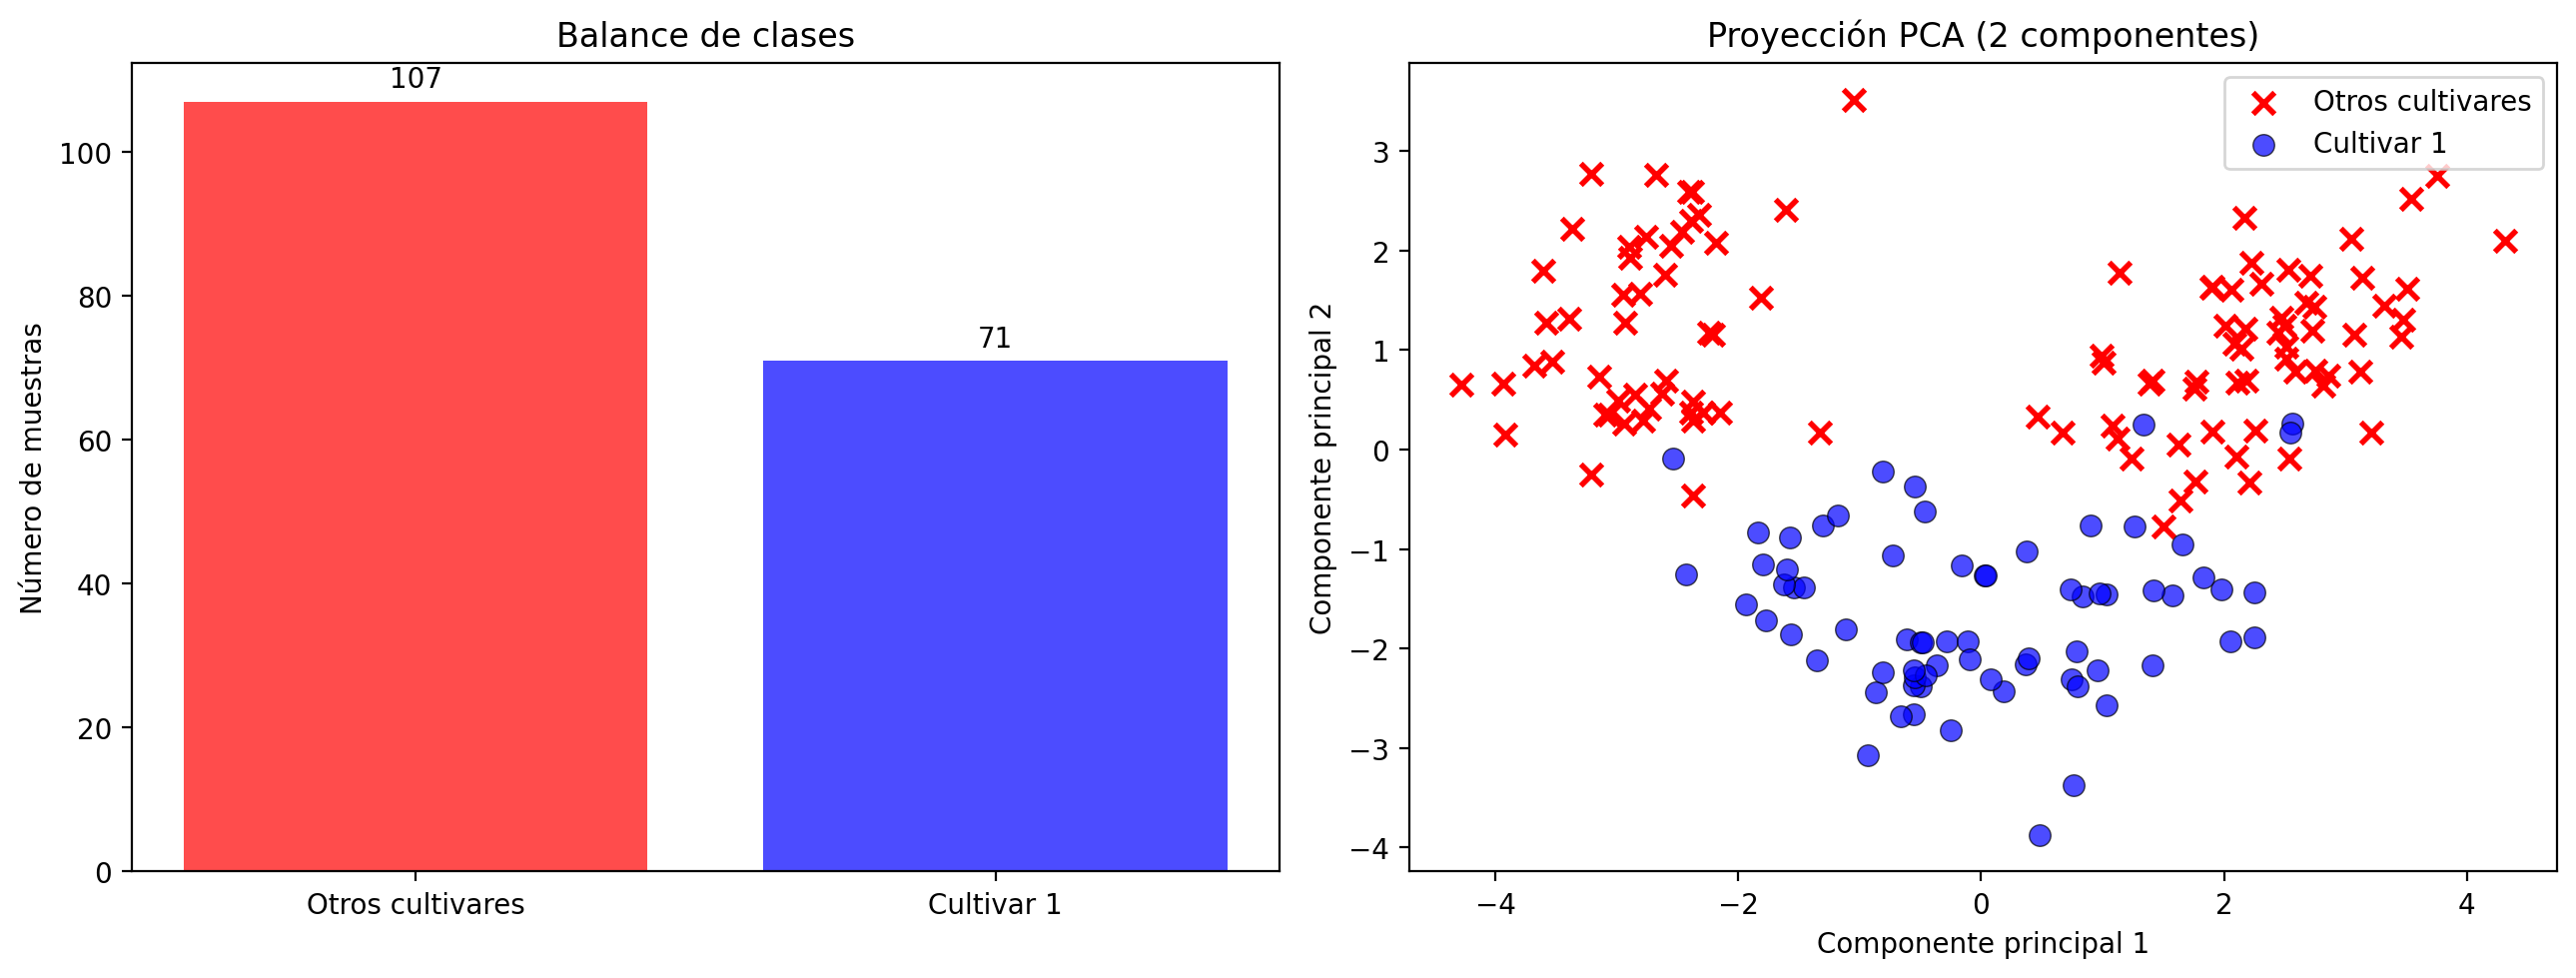

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=200)

conteos = pd.Series(y).map({0: "Otros cultivares", 1: "Cultivar 1"}).value_counts()
axes[0].bar(conteos.index, conteos.values, color=["red", "blue"], alpha=0.7)
axes[0].set_title("Balance de clases")
axes[0].set_ylabel("Número de muestras")
for i, v in enumerate(conteos.values):
    axes[0].text(i, v + 2, str(v), ha="center")

X_scaled_view = StandardScaler().fit_transform(X)
X_pca = PCA(n_components=2, random_state=26).fit_transform(X_scaled_view)

axes[1].scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], marker="x", s=60, color="red", linewidths=2, label="Otros cultivares")
axes[1].scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], marker="o", s=60, color="blue", linewidths=0.5,
                 edgecolors="black", alpha=0.7, label="Cultivar 1")
axes[1].set_title("Proyección PCA (2 componentes)")
axes[1].set_xlabel("Componente principal 1")
axes[1].set_ylabel("Componente principal 2")
axes[1].legend()

plt.tight_layout()
plt.show()

# Análisis de las máquinas de aprendizaje supervisado

## ¿Por qué necesitamos validar un modelo?

Cuando un modelo se evalúa sobre los **mismos datos** con los que fue entrenado, la métrica resultante tiende a ser optimista: el modelo puede haber memorizado detalles particulares del conjunto de entrenamiento (sobreajuste, *overfitting*) en lugar de aprender un patrón que generalice a datos nuevos. Por eso se reserva parte de los datos para *probar* el modelo con ejemplos que no vio durante el entrenamiento.

Un simple `train_test_split` (usado en la Parte I) tiene una limitación: el resultado depende de **qué muestras** cayeron por azar en el conjunto de prueba. Con un split distinto, la misma métrica podría variar solo por la composición aleatoria de esa partición. La **validación cruzada** (*cross-validation*) resuelve esto repitiendo el proceso de entrenar/probar varias veces, con particiones distintas, y agregando los resultados — de forma que la estimación final del desempeño no depende de una sola partición afortunada (o desafortunada).

## ¿Qué es Leave-One-Out Cross-Validation (LOOCV)?

**LOOCV** es el caso extremo de la validación cruzada: dado un dataset con $n$ muestras, se realizan $n$ iteraciones. En la iteración $i$:

1. Se aparta **una sola muestra**, $x_i$, como conjunto de prueba (de ahí "Leave-One-Out": se deja una fuera).
2. Se entrena el modelo con las $n-1$ muestras restantes.
3. Se predice la etiqueta de $x_i$ con el modelo recién entrenado.

Al terminar las $n$ iteraciones, **cada una de las $n$ muestras del dataset fue predicha exactamente una vez, por un modelo que nunca la vio durante el entrenamiento**. Con esas $n$ predicciones se construye una única matriz de confusión agregada y se calculan las métricas de desempeño.

Formalmente, si $D = \{(x_1,y_1), \dots, (x_n,y_n)\}$ y $f_{-i}$ denota el modelo entrenado con todo $D$ excepto $(x_i, y_i)$:

$$\hat{y}_i = f_{-i}(x_i), \qquad i = 1, \dots, n$$

**Relación con K-Folds:** LOOCV es matemáticamente un caso particular de K-Folds donde $k = n$ (cada "fold" contiene una única muestra). Esto se contrasta directamente en la Práctica 3.2 ([enlace](https://github.com/RKCbas/Maestria-en-Inteligencia-Artificial---Practicas/blob/main/Cuatrimestre%203/6%20-%20Aprendizaje%20inteligente/Practica%203/3.2.%20An%C3%A1lisis%2C%20implementaci%C3%B3n%20y%20prueba%20de%20m%C3%A1quinas%20de%20aprendizaje%20supervisado%20(Parte%20II).ipynb)), donde se usa K-Folds con $k=10$ sobre este mismo dataset.

**Ventajas:**
- Usa el máximo de datos posible para entrenar en cada iteración ($n-1$ de $n$), valioso en datasets pequeños o moderados.
- Es **determinista**: no hay aleatoriedad en cómo se arman las particiones (a diferencia de K-Folds con `shuffle=True`), por lo que dos ejecuciones siempre dan el mismo resultado.
- Aprovecha el 100% de las muestras como conjunto de prueba (acumulado), dando una estimación con muy poco sesgo (*bias*).

**Desventajas:**
- **Costo computacional alto**: exige entrenar $n$ modelos completos (178 en este caso, por cada algoritmo). Para datasets grandes o modelos costosos de entrenar puede ser impráctico.
- **Alta varianza** entre iteraciones: como los $n-1$ conjuntos de entrenamiento se solapan casi por completo entre sí, los $n$ modelos entrenados son muy parecidos entre ellos, lo que puede hacer que la estimación agregada sea sensible a las particularidades de esos datos específicos.

## Random Forest

Random Forest es un método de **ensamble** (*ensemble*): en lugar de entrenar un único modelo, entrena **muchos árboles de decisión** y combina sus predicciones. Un solo árbol de decisión tiende a sobreajustarse (memoriza el ruido de los datos de entrenamiento), pero **el promedio (o voto) de muchos árboles distintos y poco correlacionados entre sí** reduce esa varianza sin aumentar mucho el sesgo.

Para lograr que los árboles sean distintos entre sí, Random Forest introduce **dos fuentes de aleatoriedad**:

1. **Bootstrap (*bagging*):** cada árbol se entrena con una muestra aleatoria **con reemplazo** del conjunto de entrenamiento original (del mismo tamaño $n$, pero con muestras repetidas y otras ausentes). Cada árbol ve así una versión ligeramente distinta de los datos.
2. **Selección aleatoria de características:** en cada nodo del árbol, en lugar de evaluar *todas* las características disponibles para decidir el mejor corte, solo se considera un subconjunto aleatorio de ellas (típicamente $\sqrt{p}$ de las $p$ características totales, en clasificación).

**Predicción:** para clasificar una muestra nueva, cada uno de los $T$ árboles del bosque emite su propia predicción de clase, y Random Forest devuelve la **clase más votada**:

$$\hat{y} = \text{moda}\{\, \text{árbol}_1(x),\ \text{árbol}_2(x),\ \dots,\ \text{árbol}_T(x) \,\}$$

La probabilidad de pertenecer a una clase se estima como la fracción de árboles que votaron por ella.

**Hiperparámetro relevante en esta práctica:** `n_estimators` — número de árboles en el bosque (más árboles dan predicciones más estables, a costa de más tiempo de cómputo).

## Máquina de Soporte Vectorial (SVM)

Una **Support Vector Machine** busca el **hiperplano que separa las clases con el mayor margen posible**, es decir, la frontera de decisión más alejada posible de los puntos de ambas clases. Los puntos más cercanos a esa frontera —los que "sostienen" el margen— se llaman **vectores de soporte**, y son los únicos que determinan la posición del hiperplano.

Para un caso linealmente separable, la frontera de decisión es un hiperplano $w \cdot x + b = 0$, y el entrenamiento consiste en maximizar el margen $\frac{2}{\|w\|}$ sujeto a que cada punto quede correctamente clasificado fuera del margen:

$$\min_{w,b} \tfrac{1}{2}\|w\|^2 \quad \text{sujeto a} \quad y_i(w \cdot x_i + b) \geq 1 \ \ \forall i$$

En la práctica los datos casi nunca son perfectamente separables, por lo que se introduce una penalización `C` que permite que algunos puntos violen el margen: valores grandes de `C` penalizan más los errores (margen más estrecho, más ajustado a los datos); valores pequeños toleran más errores a cambio de un margen más amplio (más generalización).

**El truco del kernel (*kernel trick*):** cuando las clases no son separables por una línea recta en el espacio original, SVM puede proyectar implícitamente los datos a un espacio de mayor dimensión donde sí lo sean, sin calcular esa proyección explícitamente — solo calculando productos internos (kernels) entre pares de puntos. Aquí se usa el **kernel RBF (base radial)**:

$$K(x_i, x_j) = \exp\left(-\gamma \, \|x_i - x_j\|^2\right)$$

donde `gamma` controla qué tan "localizada" es la influencia de cada punto de entrenamiento: valores grandes hacen que cada punto influya solo en su vecindad inmediata (fronteras muy flexibles, riesgo de sobreajuste); valores pequeños extienden esa influencia más lejos (fronteras más suaves).

**Hiperparámetros relevantes en esta práctica:** `C=1.0` y `kernel="rbf"` con el `gamma` por defecto de scikit-learn (`"scale"`).

## Red Neuronal (Perceptrón Multicapa)

El **perceptrón simple** de Frank Rosenblatt es una única neurona que combina linealmente sus entradas ($z = w \cdot x + b$) y aplica una función escalón para decidir la clase. Su gran limitación es que **solo puede separar clases linealmente separables**.

El **Perceptrón Multicapa** (*Multi-Layer Perceptron*, MLP) supera esa limitación apilando varias capas de neuronas:

- Una **capa de entrada**, con una neurona por característica del dataset.
- Una o más **capas ocultas**, donde cada neurona calcula una combinación lineal de las salidas de la capa anterior y le aplica una **función de activación no lineal** (típicamente ReLU: $\text{ReLU}(z) = \max(0, z)$). Esta no linealidad es lo que permite a la red aprender fronteras de decisión curvas y complejas, no solo líneas rectas.
- Una **capa de salida**, que en clasificación binaria produce, mediante una función sigmoide, una probabilidad entre 0 y 1 de pertenecer a la clase positiva.

**Entrenamiento (backpropagation):** a diferencia del perceptrón simple (que se actualiza con la regla de Rosenblatt), el MLP se entrena minimizando una función de pérdida (entropía cruzada) mediante **descenso de gradiente**. El algoritmo de **retropropagación** (*backpropagation*) calcula, capa por capa desde la salida hacia la entrada, cuánto contribuyó cada peso al error final (aplicando la regla de la cadena del cálculo diferencial) y ajusta todos los pesos de la red en la dirección que reduce ese error.

**Hiperparámetros relevantes en esta práctica:**
- `hidden_layer_sizes=(20,)` — una sola capa oculta de 20 neuronas.
- `max_iter=500` — número máximo de épocas de entrenamiento permitidas.
- `solver="adam"` (por defecto) — variante de descenso de gradiente con tasa de aprendizaje adaptativa, adecuada para datasets pequeños/medianos.

# Implementación

Random Forest, SVM y el Perceptrón Multicapa son algoritmos considerablemente más complejos que KNN, Naive Bayes o el perceptrón simple (implementados "desde cero" en las prácticas anteriores): un bosque de cientos de árboles, la optimización cuadrática de una SVM o el descenso de gradiente con retropropagación de una red neuronal son, en la práctica, siempre delegados a bibliotecas probadas y optimizadas. Por eso aquí se utilizan las implementaciones de **scikit-learn** (`RandomForestClassifier`, `SVC`, `MLPClassifier`) para los tres algoritmos predictivos, con hiperparámetros fijos razonables (sin una búsqueda exhaustiva, que queda fuera del alcance de esta práctica).

Lo que **sí se implementa explícitamente** es el mecanismo de **LOOCV**: el ciclo que, para cada una de las $n$ muestras, la aparta, entrena con el resto, y guarda la predicción sobre la muestra apartada.

## Demostración manual del ciclo LOOCV

Para que el mecanismo quede completamente claro, primero se implementa el ciclo **a mano**, con un bucle explícito sobre `LeaveOneOut`, ejecutado sobre un subconjunto pequeño y balanceado (5 muestras de "Otros cultivares" + 5 del "Cultivar 1", para que ambas clases estén siempre presentes al entrenar) para poder observar, iteración por iteración, qué muestra se aparta, con cuántas muestras se entrena, y cuál fue la predicción resultante.

In [12]:
from sklearn.model_selection import LeaveOneOut
from sklearn.svm import SVC

# Subconjunto pequeño y balanceado (5 de "Otros cultivares" + 5 de "Cultivar 1") para que LOOCV
# siempre tenga ambas clases presentes al entrenar, sin importar qué muestra se aparte.
idx_demo = np.concatenate([np.where(y == 0)[0][:5], np.where(y == 1)[0][:5]])
X_demo, y_demo = X[idx_demo], y[idx_demo]
loo_demo = LeaveOneOut()

print(f"{'Iteración':>10} {'Índice apartado':>16} {'Etiqueta real':>14} {'Predicción':>11} {'Entrenado con':>15}")
for i, (train_idx, test_idx) in enumerate(loo_demo.split(X_demo)):
    scaler = StandardScaler().fit(X_demo[train_idx])
    X_train_i = scaler.transform(X_demo[train_idx])
    X_test_i = scaler.transform(X_demo[test_idx])

    modelo = SVC(kernel="rbf", C=1.0, random_state=26).fit(X_train_i, y_demo[train_idx])
    pred = modelo.predict(X_test_i)[0]

    print(f"{i:>10} {test_idx[0]:>16} {y_demo[test_idx[0]]:>14} {pred:>11} {len(train_idx):>12} muestras")

 Iteración  Índice apartado  Etiqueta real  Predicción   Entrenado con
         0                0              0           0            9 muestras
         1                1              0           1            9 muestras
         2                2              0           0            9 muestras
         3                3              0           0            9 muestras
         4                4              0           0            9 muestras
         5                5              1           1            9 muestras
         6                6              1           1            9 muestras
         7                7              1           1            9 muestras
         8                8              1           1            9 muestras
         9                9              1           1            9 muestras


## Ejecución completa de LOOCV sobre las 178 muestras

Repetir el ciclo anterior a mano, en Python puro, para las 178 muestras y los 3 modelos sería lento de escribir y de leer manteniendo el detalle iteración por iteración. La función `cross_val_predict` de scikit-learn implementa **exactamente el mismo procedimiento** (para cada partición de `cv`, entrena con el resto y predice sobre la parte apartada, sin usar información de esa parte durante el entrenamiento) pero lo **paraleliza** entre los núcleos del procesador con `n_jobs=-1`. Se usa `cross_val_predict(modelo, X, y, cv=LeaveOneOut(), n_jobs=-1)` para obtener, de una sola vez, las 178 predicciones fuera de muestra de cada uno de los tres modelos — una predicción por muestra, generada siempre por un modelo que no la vio durante el entrenamiento, igual que en la demostración manual.

In [13]:
import time
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

def construir_modelos():
    return {
        "Random Forest": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", RandomForestClassifier(n_estimators=100, random_state=26)),
        ]),
        "SVM": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(kernel="rbf", C=1.0, probability=True, random_state=26)),
        ]),
        "Red Neuronal (MLP)": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", MLPClassifier(hidden_layer_sizes=(20,), max_iter=500, random_state=26)),
        ]),
    }

loo = LeaveOneOut()
predicciones = {}
for nombre, pipeline in construir_modelos().items():
    t0 = time.time()
    predicciones[nombre] = cross_val_predict(pipeline, X, y, cv=loo, n_jobs=-1)
    print(f"{nombre}: LOOCV completado en {time.time() - t0:.1f} s ({X.shape[0]} entrenamientos)")

Random Forest: LOOCV completado en 17.1 s (178 entrenamientos)
SVM: LOOCV completado en 0.3 s (178 entrenamientos)
Red Neuronal (MLP): LOOCV completado en 4.9 s (178 entrenamientos)


# Evaluación de las máquinas de aprendizaje supervisado

## Métricas de evaluación

A partir de las predicciones "fuera de muestra" de cada modelo (una por cada una de las 178 muestras, generada siempre por un modelo que no la vio durante el entrenamiento) se construye una **matriz de confusión agregada**. Se define **Cultivar 1** como la clase **positiva** (frente a "Otros cultivares" como clase negativa), siguiendo la binarización uno-contra-el-resto definida al cargar el dataset:

- **VP (Verdaderos Positivos):** vinos del Cultivar 1 correctamente identificados como tales.
- **VN (Verdaderos Negativos):** vinos de otros cultivares correctamente identificados como tales.
- **FP (Falsos Positivos):** vinos de otros cultivares incorrectamente clasificados como Cultivar 1.
- **FN (Falsos Negativos):** vinos del Cultivar 1 incorrectamente clasificados como de otro cultivar.

Con $N = VP+VN+FP+FN$:

| Métrica | Fórmula | Interpretación |
|---|---|---|
| Precisión Global | $\frac{VP+VN}{N}$ | Proporción total de aciertos (exactitud) |
| Error Global | $\frac{FP+FN}{N}$ | Proporción total de errores ($=1-$ Precisión Global) |
| Precisión Positiva (PP) | $\frac{VP}{VP+FN}$ | De los vinos realmente del Cultivar 1, ¿qué fracción detectó el modelo? (sensibilidad) |
| Precisión Negativa (PN) | $\frac{VN}{VN+FP}$ | De los vinos de otros cultivares, ¿qué fracción identificó correctamente? (especificidad) |
| Falsos Positivos (tasa) | $\frac{FP}{FP+VN}$ | De los vinos de otros cultivares, ¿qué fracción se clasificó erróneamente como Cultivar 1? |
| Falsos Negativos (tasa) | $\frac{FN}{FN+VP}$ | De los vinos del Cultivar 1, ¿qué fracción se clasificó erróneamente como de otro cultivar? |
| Asertividad Positiva (AP) | $\frac{VP}{VP+FP}$ | De los casos marcados como Cultivar 1, ¿qué fracción realmente lo era? (precisión) |
| Asertividad Negativa (NP) | $\frac{VN}{VN+FN}$ | De los casos marcados como otros cultivares, ¿qué fracción realmente lo era? (valor predictivo negativo) |

In [14]:
def calcular_metricas(y_true, y_pred, clase_positiva=1):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    VP = np.sum((y_true == clase_positiva) & (y_pred == clase_positiva))
    VN = np.sum((y_true != clase_positiva) & (y_pred != clase_positiva))
    FP = np.sum((y_true != clase_positiva) & (y_pred == clase_positiva))
    FN = np.sum((y_true == clase_positiva) & (y_pred != clase_positiva))
    N = VP + VN + FP + FN

    return {
        "VP": VP, "VN": VN, "FP": FP, "FN": FN,
        "Precisión Global": (VP + VN) / N,
        "Error Global": (FP + FN) / N,
        "PP": VP / (VP + FN),
        "PN": VN / (VN + FP),
        "Tasa FP": FP / (FP + VN),
        "Tasa FN": FN / (FN + VP),
        "AP": VP / (VP + FP),
        "NP": VN / (VN + FN),
    }


tabla_metricas = pd.DataFrame({
    nombre: calcular_metricas(y, pred) for nombre, pred in predicciones.items()
}).T
tabla_metricas[["VP", "VN", "FP", "FN"]] = tabla_metricas[["VP", "VN", "FP", "FN"]].astype(int)
tabla_metricas.round(4)

,VP,VN,FP,FN,Precisión Global,Error Global,PP,PN,Tasa FP,Tasa FN,AP,NP
Random Forest,68,107,0,3,0.9831,0.0169,0.9577,1.0000,0.0000,0.0423,1.0000,0.9727
SVM,70,105,2,1,0.9831,0.0169,0.9859,0.9813,0.0187,0.0141,0.9722,0.9906
Red Neuronal (MLP),69,106,1,2,0.9831,0.0169,0.9718,0.9907,0.0093,0.0282,0.9857,0.9815


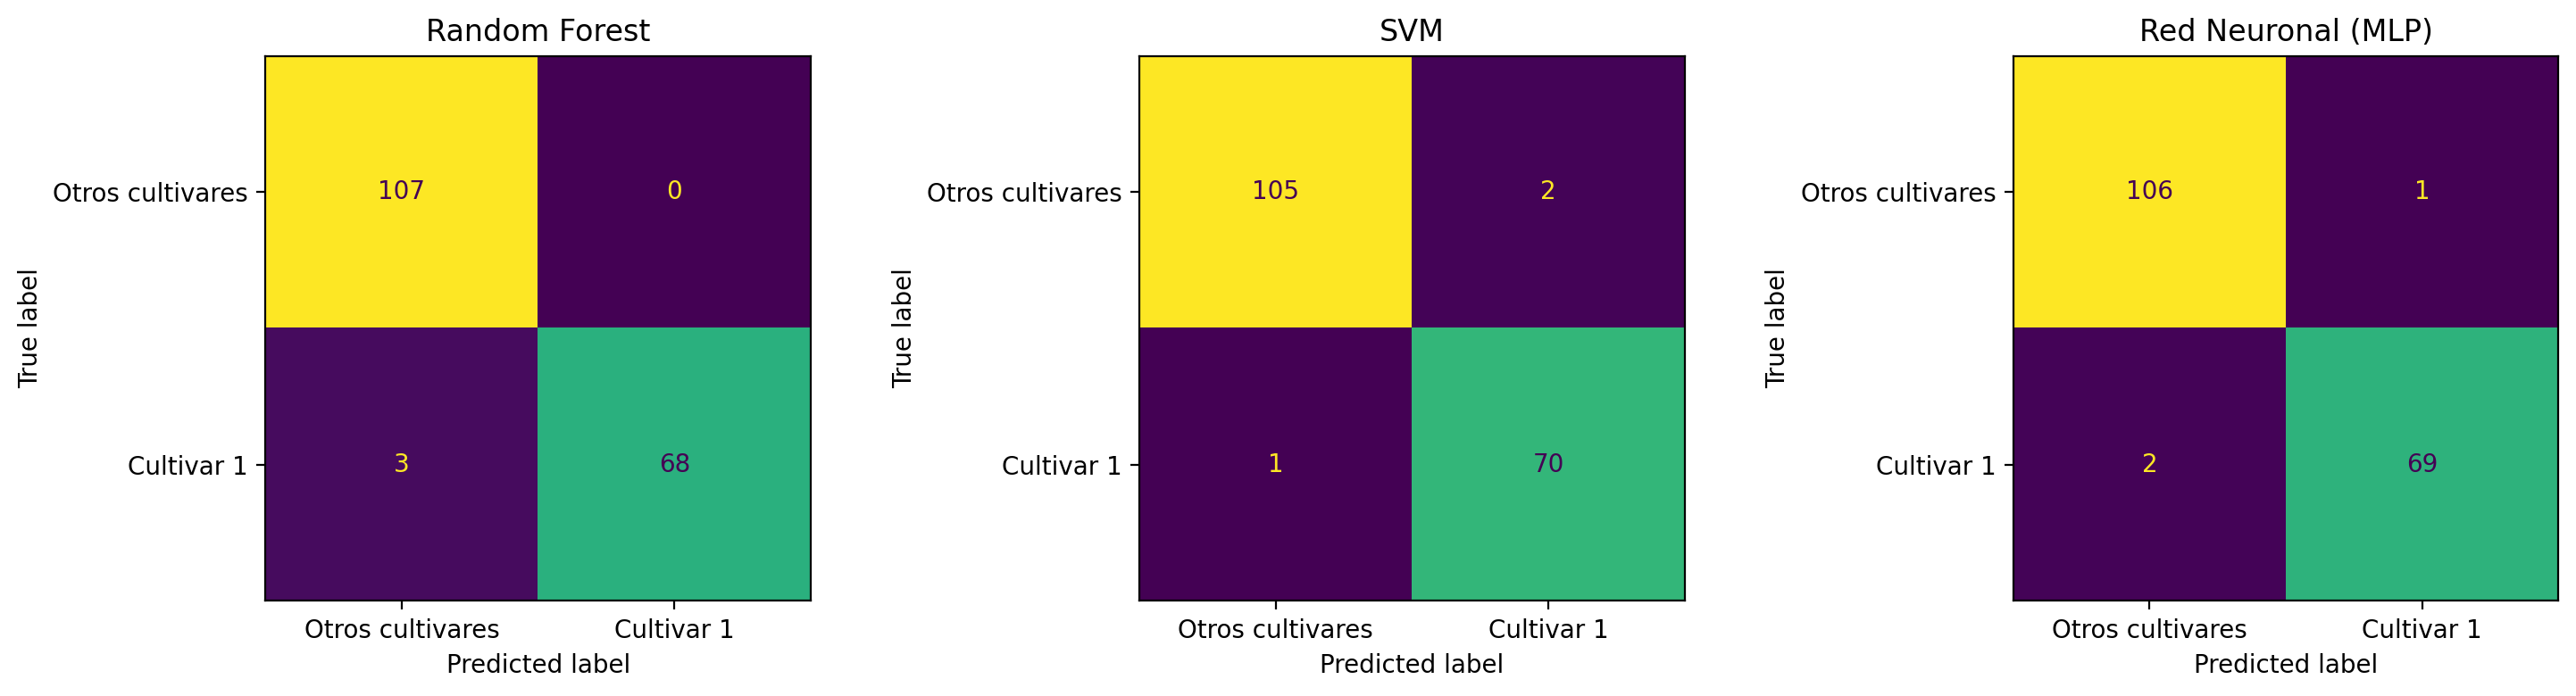

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, len(predicciones), figsize=(5 * len(predicciones), 4), dpi=200)
for ax, (nombre, pred) in zip(axes, predicciones.items()):
    ConfusionMatrixDisplay.from_predictions(
        y, pred, display_labels=["Otros cultivares", "Cultivar 1"], ax=ax, colorbar=False
    )
    ax.set_title(nombre)
plt.tight_layout()
plt.show()

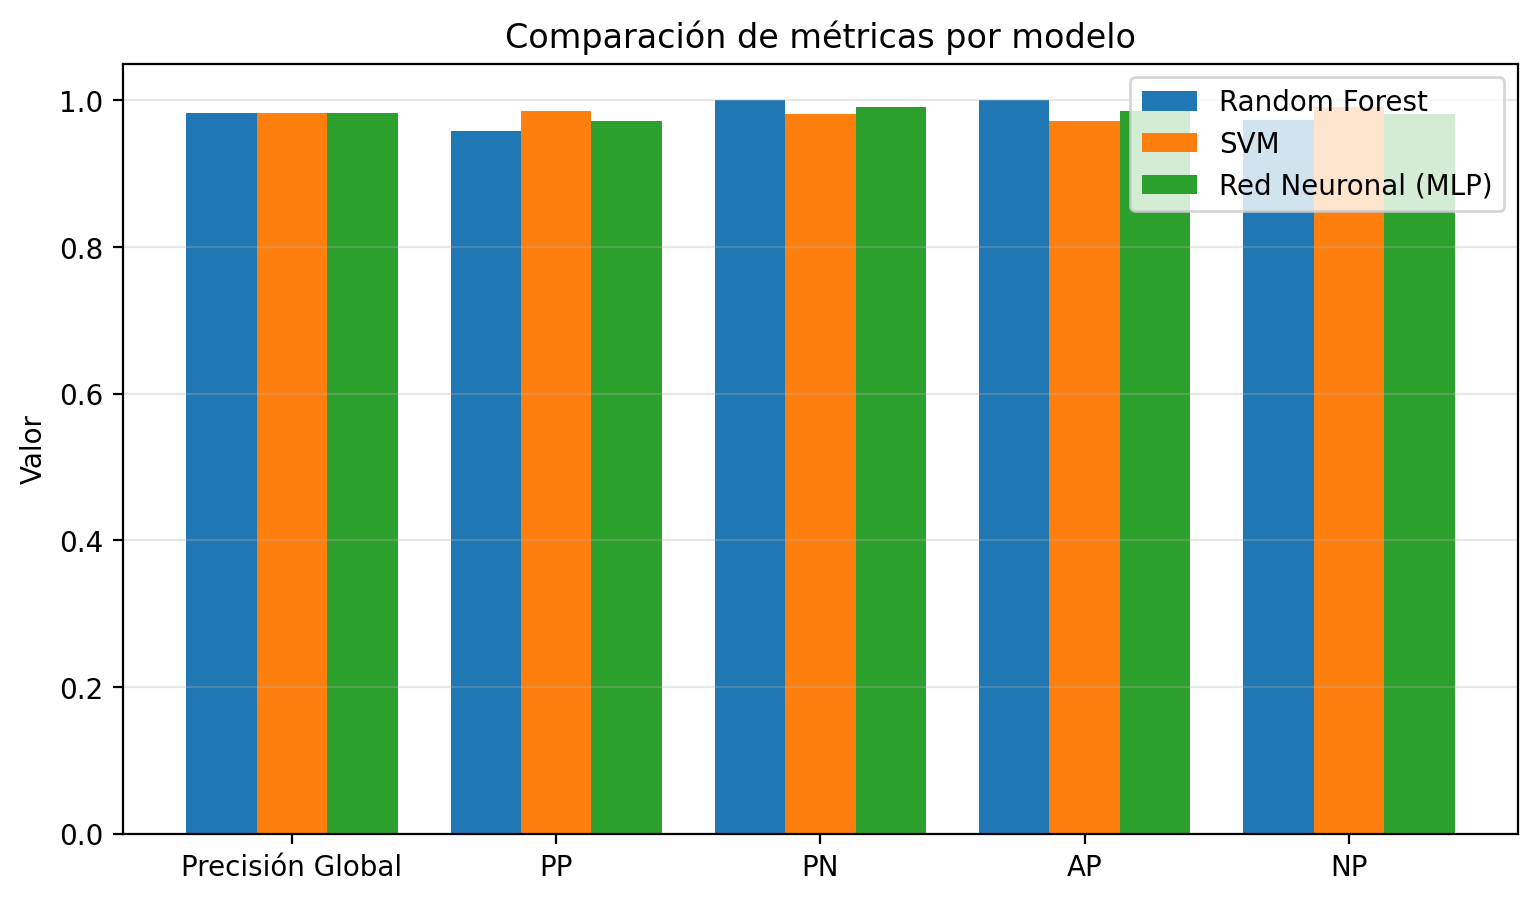

In [16]:
metricas_plot = ["Precisión Global", "PP", "PN", "AP", "NP"]
x = np.arange(len(metricas_plot))
ancho = 0.8 / len(predicciones)

plt.figure(figsize=(9, 5), dpi=200)
for i, nombre in enumerate(predicciones):
    valores = tabla_metricas.loc[nombre, metricas_plot].values.astype(float)
    plt.bar(x + i * ancho, valores, width=ancho, label=nombre)

plt.xticks(x + ancho * (len(predicciones) - 1) / 2, metricas_plot)
plt.ylim(0, 1.05)
plt.ylabel("Valor")
plt.title("Comparación de métricas por modelo")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

## Análisis comparativo

Con las 178 predicciones LOOCV (una por muestra), los resultados fueron:

| Modelo | Precisión Global | Error Global | PP | PN | Tasa FP | Tasa FN | AP | NP |
|---|---|---|---|---|---|---|---|---|
| Random Forest | 0.9831 | 0.0169 | 0.9577 | 1.0000 | 0.0000 | 0.0423 | 1.0000 | 0.9727 |
| SVM | 0.9831 | 0.0169 | 0.9859 | 0.9813 | 0.0187 | 0.0141 | 0.9722 | 0.9906 |
| Red Neuronal (MLP) | 0.9831 | 0.0169 | 0.9718 | 0.9907 | 0.0093 | 0.0282 | 0.9857 | 0.9815 |

**Lectura de resultados:**

- Los tres modelos alcanzaron exactamente la misma **Precisión Global** (0.9831) y el mismo **Error Global** (0.0169): de las 178 muestras, cada modelo se equivocó en solo 3 — pero no en las mismas 3, ni del mismo tipo de error.
- **Random Forest** no cometió ningún Falso Positivo (AP = 1.0000, Tasa FP = 0.0000): cada vez que predijo "Cultivar 1" acertó. A cambio, tuvo la mayor Tasa de Falsos Negativos (0.0423): 3 vinos del Cultivar 1 fueron clasificados como "Otros cultivares".
- **SVM** obtuvo la mejor Precisión Positiva (PP = 0.9859): detectó más vinos del Cultivar 1 que los otros dos modelos (solo 1 Falso Negativo), pero a cambio cometió 2 Falsos Positivos, la mayor cantidad de los tres.
- La **Red Neuronal (MLP)** quedó en un punto intermedio entre Random Forest y SVM en casi todas las métricas, con 1 Falso Positivo y 2 Falsos Negativos.
- A diferencia del comportamiento típico en datasets más desbalanceados, aquí las métricas de ambas clases (PP/AP para la positiva, PN/NP para la negativa) son todas muy altas y comparables entre sí (>0.95), lo que confirma que las 13 características químicas del dataset Wine separan muy bien al Cultivar 1 del resto.

# Conclusiones

Implementar el ciclo de **LOOCV** explícitamente —primero a mano sobre un subconjunto pequeño, y después a escala completa sobre las 178 muestras usando `cross_val_predict` con `cv=LeaveOneOut()`— permitió comprobar de primera mano su definición: cada una de las 178 muestras fue predicha exactamente una vez, por un modelo entrenado únicamente con las 177 restantes, sin que ninguna predicción usara información de la propia muestra evaluada.

Sobre el dataset Wine recognition (binarizado a Cultivar 1 vs. Otros cultivares), **los tres modelos (Random Forest, SVM y Red Neuronal) alcanzaron un desempeño muy alto y prácticamente idéntico en Precisión Global** (0.9831 los tres), lo cual confirma que las 13 características químicas del dataset son muy informativas para distinguir el Cultivar 1 del resto, independientemente del mecanismo de aprendizaje usado (árboles combinados, márgenes máximos o redes con retropropagación).

**Ningún modelo dominó de forma absoluta**: aunque los tres cometieron el mismo número total de errores (3 de 178), el tipo de error varió — Random Forest priorizó no generar Falsos Positivos (AP = 1.0000) a costa de más Falsos Negativos, SVM minimizó los Falsos Negativos (PP = 0.9859) a costa de algunos Falsos Positivos, y la Red Neuronal quedó en un punto intermedio. La elección entre ellos, en un caso real, dependería de qué tipo de error resulte más costoso para el problema.

En cuanto a la **técnica de validación**, LOOCV resultó exhaustiva: entrenar 178 modelos por algoritmo (534 entrenamientos en total) tomó apenas segundos gracias a la paralelización con `n_jobs=-1`; un ciclo secuencial equivalente, sin paralelizar, habría tomado bastante más tiempo. Esta característica de LOOCV —usar el máximo de datos posible para entrenar en cada iteración, a cambio de un costo computacional que crece linealmente con el número de muestras— se contrasta directamente con K-Folds en la Práctica 3.2 ([enlace](https://github.com/RKCbas/Maestria-en-Inteligencia-Artificial---Practicas/blob/main/Cuatrimestre%203/6%20-%20Aprendizaje%20inteligente/Practica%203/3.2.%20An%C3%A1lisis%2C%20implementaci%C3%B3n%20y%20prueba%20de%20m%C3%A1quinas%20de%20aprendizaje%20supervisado%20(Parte%20II).ipynb)), donde el mismo dataset y los mismos tres modelos se evalúan con una técnica computacionalmente más económica.

## Referencias

James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning with Applications in R* (2nd ed.). Springer. [https://doi.org/10.1007/978-1-0716-1418-1](https://doi.org/10.1007/978-1-0716-1418-1)

Scikit-learn developers. (s.f.). *sklearn.model_selection.LeaveOneOut*. Scikit-learn 1.7 documentation. [https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.LeaveOneOut.html](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.LeaveOneOut.html)

Hernández Parada, M. S. (2026). *3.2. Análisis, implementación y prueba de máquinas de aprendizaje supervisado (Parte II)* [Jupyter notebook]. GitHub. [https://github.com/RKCbas/Maestria-en-Inteligencia-Artificial---Practicas/blob/main/Cuatrimestre%203/6%20-%20Aprendizaje%20inteligente/Practica%203/3.2.%20An%C3%A1lisis%2C%20implementaci%C3%B3n%20y%20prueba%20de%20m%C3%A1quinas%20de%20aprendizaje%20supervisado%20(Parte%20II).ipynb](https://github.com/RKCbas/Maestria-en-Inteligencia-Artificial---Practicas/blob/main/Cuatrimestre%203/6%20-%20Aprendizaje%20inteligente/Practica%203/3.2.%20An%C3%A1lisis%2C%20implementaci%C3%B3n%20y%20prueba%20de%20m%C3%A1quinas%20de%20aprendizaje%20supervisado%20(Parte%20II).ipynb)

Aeberhard, S., Coomans, D., & de Vel, O. (1992). *Wine* [Dataset]. UCI Machine Learning Repository. [https://doi.org/10.24432/C5PC7J](https://doi.org/10.24432/C5PC7J)

Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5–32. [https://doi.org/10.1023/A:1010933404324](https://doi.org/10.1023/A:1010933404324)

Cortes, C., & Vapnik, V. (1995). Support-vector networks. *Machine Learning*, 20(3), 273–297. [https://doi.org/10.1007/BF00994018](https://doi.org/10.1007/BF00994018)

Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). Learning representations by back-propagating errors. *Nature*, 323(6088), 533–536. [https://doi.org/10.1038/323533a0](https://doi.org/10.1038/323533a0)

Hernández Orallo, J., Ramírez Quintana, M. J., & Ferri Ramírez, C. (2004). *Introducción a la minería de datos*. Pearson Educación.

Scikit-learn developers. (s.f.). *sklearn.ensemble.RandomForestClassifier*. Scikit-learn 1.7 documentation. [https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

Scikit-learn developers. (s.f.). *sklearn.svm.SVC*. Scikit-learn 1.7 documentation. [https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)

Scikit-learn developers. (s.f.). *sklearn.neural_network.MLPClassifier*. Scikit-learn 1.7 documentation. [https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)

Hernández Parada, M. S. (2026). *Maestría en Inteligencia Artificial — Prácticas* [Repositorio de GitHub]. GitHub. [https://github.com/RKCbas/Maestria-en-Inteligencia-Artificial---Practicas/blob/main/Cuatrimestre%203/6%20-%20Aprendizaje%20inteligente/Practica%203/3.1.%20An%C3%A1lisis%2C%20implementaci%C3%B3n%20y%20prueba%20de%20m%C3%A1quinas%20de%20aprendizaje%20supervisado%20(Parte%20II).ipynb](https://github.com/RKCbas/Maestria-en-Inteligencia-Artificial---Practicas/blob/main/Cuatrimestre%203/6%20-%20Aprendizaje%20inteligente/Practica%203/3.1.%20An%C3%A1lisis%2C%20implementaci%C3%B3n%20y%20prueba%20de%20m%C3%A1quinas%20de%20aprendizaje%20supervisado%20(Parte%20II).ipynb)